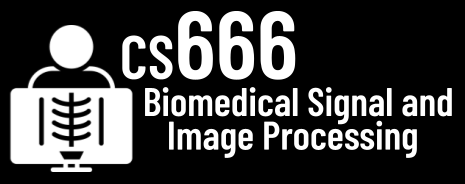
#Assignment 6

In [72]:
# NAME: Fasiur Rehman

In [73]:
# In this assignment, we will visualize and explore a CT scan!

In [74]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [38]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [39]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [40]:
# TODO: YOUR CODE
!wget https://cs666.org/data/ct.zip

--2026-05-07 02:15:28--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip.1’

ct.zip.1            100%[===================>]   5.58M  --.-KB/s    in 0.04s   

2026-05-07 02:15:28 (140 MB/s) - ‘ct.zip.1’ saved [5847706/5847706]



In [41]:
# Then use the following snippet to extract the data.

In [42]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [43]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [44]:
# TODO: YOUR_ANSWER: 220

In [45]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [46]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

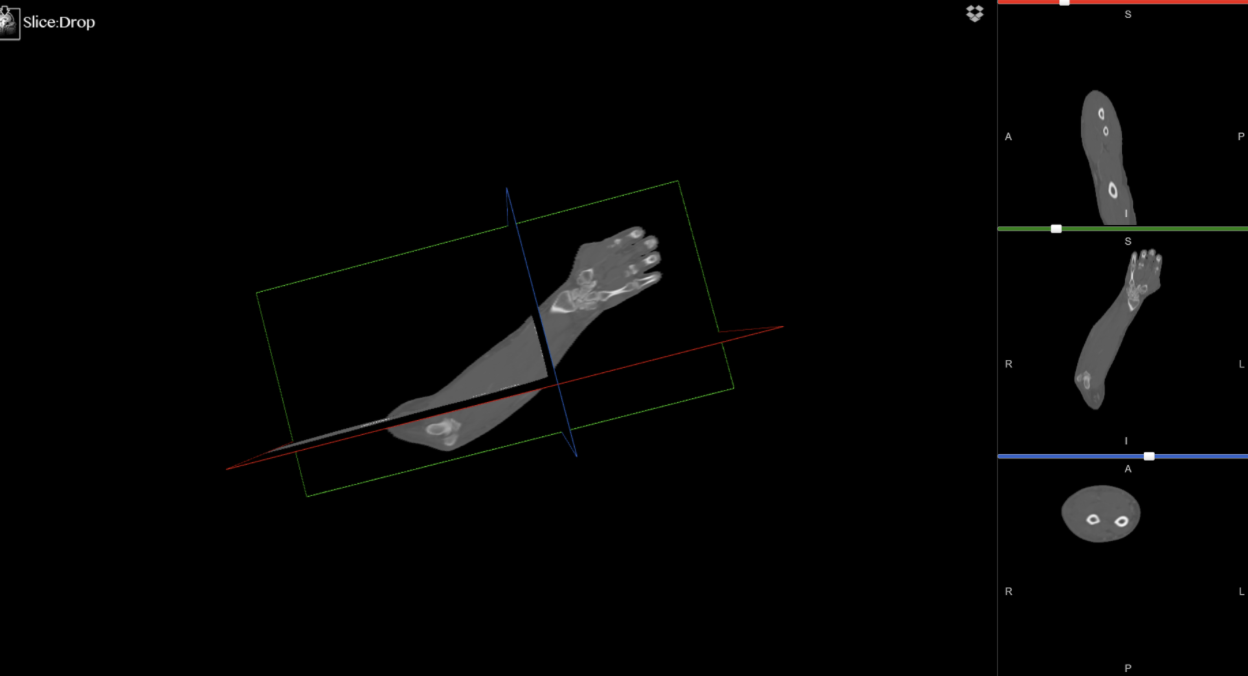

In [47]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [48]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

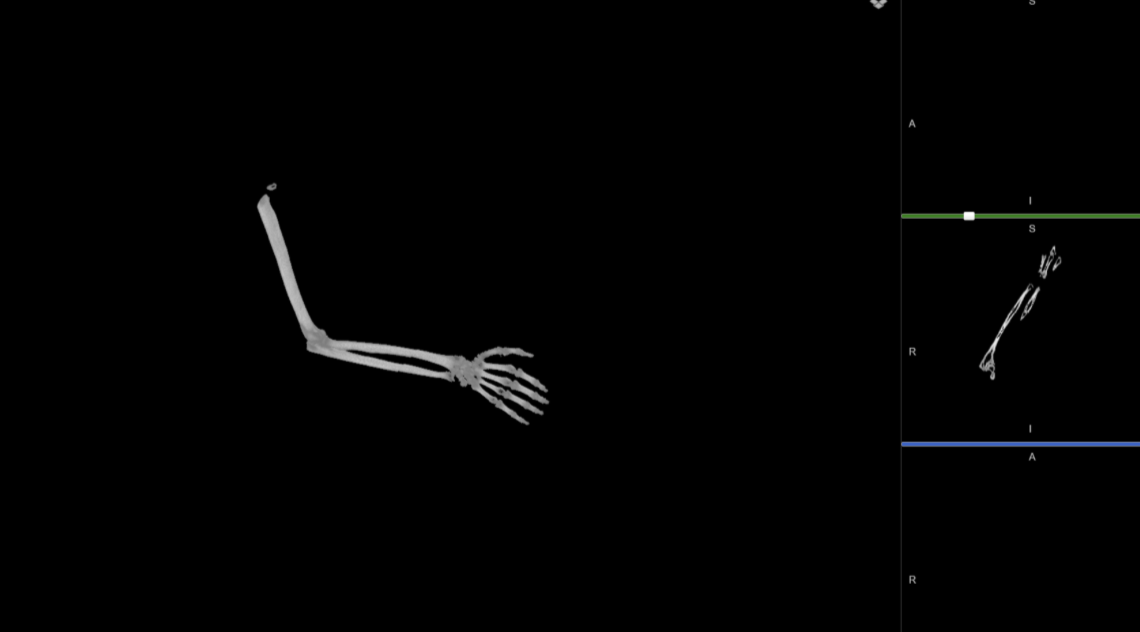

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [49]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [50]:
from pydicom import dcmread

In [51]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY
import os
import numpy as np
ct ='ct'
ct_files = os.listdir(ct)
ct_files.sort()

first_file = dcmread(os.path.join(ct, ct_files[0]))
size=[len(ct_files)]
dimensions = list(first_file.pixel_array.shape)

dim=dimensions+size
ct_numpy = np.zeros(dim, dtype=np.int32)
print(dim)
for i in range(len(ct_files)):
    file_name = ct_files[i]
    file_path = os.path.join(ct, file_name)
    dicom_file = dcmread(file_path)
    ct_numpy[:, :, i] = dicom_file.pixel_array


[454, 512, 220]


In [52]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

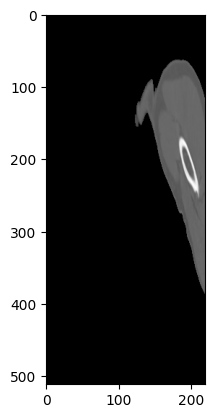

In [53]:
# TODO: YOUR CODE FOR
import matplotlib.pyplot as plt


axial = ct_numpy[215, :,:]
plt.imshow(axial, cmap='gray')
plt.show()

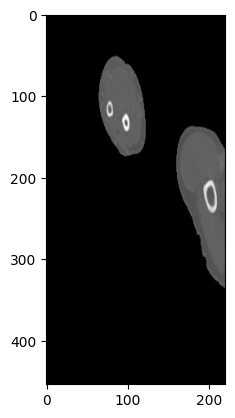

In [54]:
# TODO: YOUR CODE FOR SAGITTAL
sagittal = ct_numpy[:, 220, :]
plt.imshow(sagittal, cmap='gray')
plt.show()

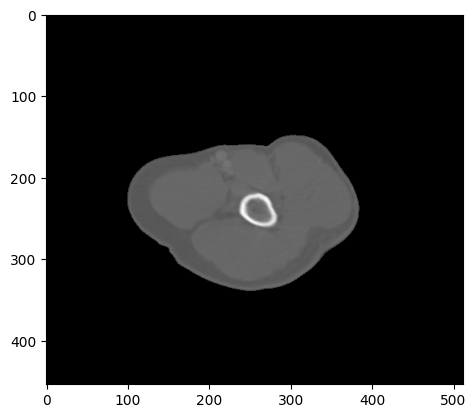

In [55]:
# TODO: YOUR CODE FOR CORONAL
coronal = ct_numpy[:,:, 215]
plt.imshow(coronal, cmap='gray')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [56]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [57]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [58]:
# TODO: YOUR CODE
level = dicom_file.WindowCenter
width = dicom_file.WindowWidth
rescale = dicom_file['RescaleIntercept'].value


In [59]:
# 2) Play around with different Window/Level values that enhance
# the visualization.



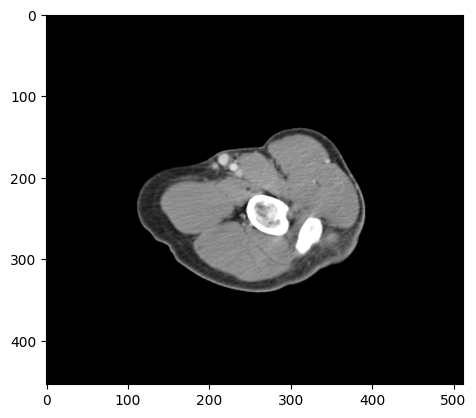

In [60]:
# TODO: YOUR CODE
hu_pixels=dicom_file.pixel_array
vmin = level - width/2
vmax = level + width/2
plt.imshow( hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()


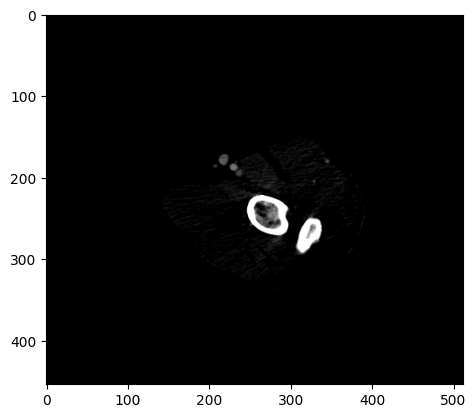

In [61]:
level = 200
width= 300
vmin = level - width/2
vmax = level + width/2
plt.imshow( hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

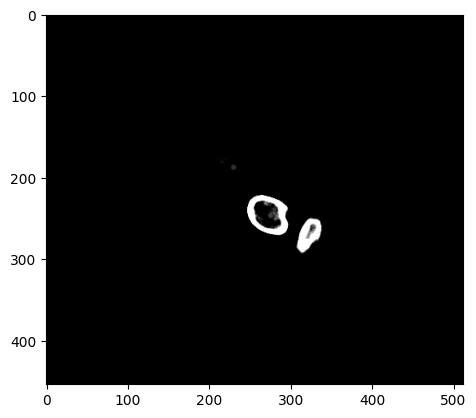

In [62]:
level = 250
width= 200
vmin = level - width/2
vmax = level + width/2
plt.imshow( hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

In [63]:
# Which values make sense and why?

In [64]:
# TODO: YOUR ANSWER
# The appropriate values depend on the type of segmentation the user wants to visualize, so selecting the thresholds based on the specific requirement makes the most sense.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [65]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

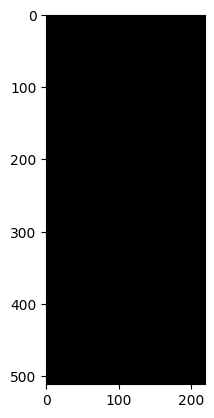

In [66]:
# TODO: YOUR CODE TO SEGMENT FAT
new_mask = ct_numpy[120].copy().astype(np.int16)
new_mask[(new_mask > -100)|(new_mask < -60)] = 0
plt.imshow(new_mask, cmap='gray')
plt.show()

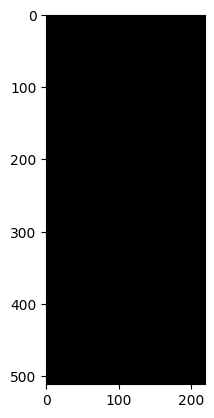

In [67]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE
new_mask = ct_numpy[120].copy().astype(np.int16)
new_mask[(new_mask <40 )|(new_mask > 80)] = 0
plt.imshow(new_mask, cmap='gray')
plt.show()

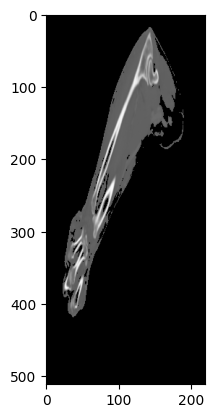

In [68]:
# TODO: YOUR CODE TO SEGMENT BONES
new_m = ct_numpy[120].copy().astype(np.int16)
new_m[new_m < 1000] = 0
plt.imshow(new_m, cmap='gray')
plt.show()

In [69]:
# Are the segmentations good?

In [70]:
# TODO: YOUR ANSWER
# The segmentations for fat, soft tissue, and bone are not producing good results when based solely on Hounsfield Unit thresholds.

In [71]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""